# SECB3203 - Programming for Bioinformatics
## Group 10 - Pancreatic Cancer Prediction
###  Group Members
- WELSON WOONG LU BIN (A23CS0196)
- RAVINESH A/L MARAN (A23CS0175)
- BERNICE LOU MIN YUN (A23CS0056)


---
## Import Libraries (Machine Learning and Prediction)

In [1]:
# For EDA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, RobustScaler

# For Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression, BayesianRidge
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.exceptions import FitFailedWarning

---

## Progress 2 
### Importing Data Set
  - Understanding the data
  - Importing and exporting data in Python
  - Getting started analyzing data in Python
  - Python packages for Data Science




In [2]:
# import dataset from csv to python 
df = pd.read_csv(r"C:\bioinfo2\p4b\project\Pancrease_Cancer_Prediction\pancreatic_cancer_prediction_sample.csv")
df.head()

,Country,Age,Gender,Smoking_History,Obesity,Diabetes,Chronic_Pancreatitis,Family_History,Hereditary_Condition,Jaundice,...,Stage_at_Diagnosis,Survival_Time_Months,Treatment_Type,Survival_Status,Alcohol_Consumption,Physical_Activity_Level,Diet_Processed_Food,Access_to_Healthcare,Urban_vs_Rural,Economic_Status
0,Canada,64,Female,0,0,0,0,0,0,0,...,Stage III,13,Surgery,0,0,Medium,Low,High,Urban,Low
1,South Africa,77,Male,1,1,0,0,0,0,0,...,Stage III,13,Chemotherapy,0,1,Medium,Medium,Medium,Urban,Low
2,India,71,Female,0,0,0,0,0,0,0,...,Stage IV,3,Chemotherapy,1,0,Medium,High,Low,Rural,Middle
3,Germany,56,Male,0,0,0,0,1,0,1,...,Stage IV,6,Radiation,0,1,Low,Low,Medium,Rural,Middle
4,United States,82,Female,0,0,0,0,1,0,0,...,Stage IV,9,Chemotherapy,1,0,Low,Medium,Medium,Rural,Low


In [3]:
# export dataset 
df.to_csv("pancreatic_cancer_data_processed.csv", index=False)


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,50000.0,64.54094,9.973847,30.0,58.0,65.0,71.0,90.0
Smoking_History,50000.0,0.29954,0.458061,0.0,0.0,0.0,1.0,1.0
Obesity,50000.0,0.24826,0.432008,0.0,0.0,0.0,0.0,1.0
Diabetes,50000.0,0.19998,0.399989,0.0,0.0,0.0,0.0,1.0
Chronic_Pancreatitis,50000.0,0.09930,0.299067,0.0,0.0,0.0,0.0,1.0
Family_History,50000.0,0.15168,0.358714,0.0,0.0,0.0,0.0,1.0
Hereditary_Condition,50000.0,0.04944,0.216787,0.0,0.0,0.0,0.0,1.0
Jaundice,50000.0,0.19922,0.399418,0.0,0.0,0.0,0.0,1.0
Abdominal_Discomfort,50000.0,0.29650,0.456719,0.0,0.0,0.0,1.0,1.0
Back_Pain,50000.0,0.25286,0.434656,0.0,0.0,0.0,1.0,1.0


In [5]:
df.describe(include='object').T

,count,unique,top,freq
Country,50000,9,United States,17608
Gender,50000,2,Male,25962
Stage_at_Diagnosis,50000,4,Stage IV,19922
Treatment_Type,50000,3,Chemotherapy,24910
Physical_Activity_Level,50000,3,Medium,20038
Diet_Processed_Food,50000,3,Medium,20122
Access_to_Healthcare,50000,3,Medium,25268
Urban_vs_Rural,50000,2,Urban,35003
Economic_Status,50000,3,Middle,24881


### Data Wrangling (Pandas / Numpy)
  - Identifying and handling missing values
  - Data formatting
  - Data normalization (centering/scaling)
  - Binning
  - Indicator variables

In [6]:
# missing value and duplicate value check
print('Missing Value (%)')
print(df.isna().mean()*100)
print('\nDuplicate Row (%)')
print(df.duplicated().mean())

Missing Value (%)
Country                          0.0
Age                              0.0
Gender                           0.0
Smoking_History                  0.0
Obesity                          0.0
Diabetes                         0.0
Chronic_Pancreatitis             0.0
Family_History                   0.0
Hereditary_Condition             0.0
Jaundice                         0.0
Abdominal_Discomfort             0.0
Back_Pain                        0.0
Weight_Loss                      0.0
Development_of_Type2_Diabetes    0.0
Stage_at_Diagnosis               0.0
Survival_Time_Months             0.0
Treatment_Type                   0.0
Survival_Status                  0.0
Alcohol_Consumption              0.0
Physical_Activity_Level          0.0
Diet_Processed_Food              0.0
Access_to_Healthcare             0.0
Urban_vs_Rural                   0.0
Economic_Status                  0.0
dtype: float64

Duplicate Row (%)
8e-05


In [7]:
print("Number of duplicate rows BEFORE removal:", df.duplicated().sum())
df.drop_duplicates(inplace=True)
print("Number of duplicate rows AFTER removal:", df.duplicated().sum())



Number of duplicate rows BEFORE removal: 4
Number of duplicate rows AFTER removal: 0


In [8]:
# standardise column names and text values for stage_at_diagnosis
df.columns = df.columns.str.lower()
df['gender'] = df['gender'].str.lower()
df['stage_at_diagnosis'] = df['stage_at_diagnosis'].str.replace(' ', '_')

print(df.columns)
print(df['gender'].unique())
print(df['stage_at_diagnosis'].unique())



Index(['country', 'age', 'gender', 'smoking_history', 'obesity', 'diabetes',
       'chronic_pancreatitis', 'family_history', 'hereditary_condition',
       'jaundice', 'abdominal_discomfort', 'back_pain', 'weight_loss',
       'development_of_type2_diabetes', 'stage_at_diagnosis',
       'survival_time_months', 'treatment_type', 'survival_status',
       'alcohol_consumption', 'physical_activity_level', 'diet_processed_food',
       'access_to_healthcare', 'urban_vs_rural', 'economic_status'],
      dtype='object')
['female' 'male']
['Stage_III' 'Stage_IV' 'Stage_II' 'Stage_I']


In [9]:
# data normalization
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[['age', 'survival_time_months']] = scaler.fit_transform(
    df[['age', 'survival_time_months']]
)

# actual
print(df[['age', 'survival_time_months']].describe())

# rounded
desc = df[['age', 'survival_time_months']].describe()
desc.loc['count'] = desc.loc['count'].astype(int)
desc.round(10)

                age  survival_time_months
count  4.999600e+04          4.999600e+04
mean   3.612688e-16         -4.093054e-17
std    1.000010e+00          1.000010e+00
min   -3.463106e+00         -1.144306e+00
25%   -6.558025e-01         -7.007351e-01
50%    4.602341e-02         -3.458782e-01
75%    6.475885e-01          4.525496e-01
max    2.552545e+00          4.001118e+00


,age,survival_time_months
count,49996.000000,49996.000000
mean,0.000000,-0.000000
std,1.000010,1.000010
min,-3.463106,-1.144306
25%,-0.655803,-0.700735
50%,0.046023,-0.345878
75%,0.647588,0.452550
max,2.552545,4.001118


In [10]:
# binning age column
#  avg = 64.54
df['age_group'] = pd.cut(
    df['age'],
    bins=[-3, -1, 0, 3],   # scaled values after StandardScaler
    labels=['Below-Average', 'Average', 'Above-Average']
)

print(df[['age', 'age_group']].head(10))
print(df['age_group'].value_counts())


        age      age_group
0 -0.054237        Average
1  1.249154  Above-Average
2  0.647588  Above-Average
3 -0.856324        Average
4  1.750458  Above-Average
5 -1.558150  Below-Average
6  0.246545  Above-Average
7 -0.856324        Average
8 -1.457889  Below-Average
9 -1.157107  Below-Average
age_group
Above-Average    25158
Average          16994
Below-Average     7776
Name: count, dtype: int64


In [11]:
# indicator variable 
df_encoded = pd.get_dummies(
    df,
    columns=['gender', 'treatment_type', 'stage_at_diagnosis', 'urban_vs_rural',
             'country', 'physical_activity_level', 'diet_processed_food', 
             'access_to_healthcare', 'economic_status', 'age_group'],
    drop_first=True
)

print(df_encoded.columns)
print(df_encoded.head())

Index(['age', 'smoking_history', 'obesity', 'diabetes', 'chronic_pancreatitis',
       'family_history', 'hereditary_condition', 'jaundice',
       'abdominal_discomfort', 'back_pain', 'weight_loss',
       'development_of_type2_diabetes', 'survival_time_months',
       'survival_status', 'alcohol_consumption', 'gender_male',
       'treatment_type_Radiation', 'treatment_type_Surgery',
       'stage_at_diagnosis_Stage_II', 'stage_at_diagnosis_Stage_III',
       'stage_at_diagnosis_Stage_IV', 'urban_vs_rural_Urban', 'country_Brazil',
       'country_Canada', 'country_China', 'country_Germany', 'country_India',
       'country_South Africa', 'country_United Kingdom',
       'country_United States', 'physical_activity_level_Low',
       'physical_activity_level_Medium', 'diet_processed_food_Low',
       'diet_processed_food_Medium', 'access_to_healthcare_Low',
       'access_to_healthcare_Medium', 'economic_status_Low',
       'economic_status_Middle', 'age_group_Average',
       'age_gro

---

## Project Progress 3
### Exploratory Data Analysis (Pandas/Numpy)
  - Descriptive statistics
  - Basic of grouping
  - ANOVA
  - Correlation


In [12]:
# descriptive statistic

desc_numeric = df[['age', 'survival_time_months']].describe()
print(desc_numeric)

#binary variable 
categorical_cols = [
    'gender', 
    'stage_at_diagnosis',
    'treatment_type',
    'smoking_history',
    'survival_status'
]

for col in categorical_cols:
    print(f"\n{col} distribution:")
    print(df[col].value_counts())

                age  survival_time_months
count  4.999600e+04          4.999600e+04
mean   3.612688e-16         -4.093054e-17
std    1.000010e+00          1.000010e+00
min   -3.463106e+00         -1.144306e+00
25%   -6.558025e-01         -7.007351e-01
50%    4.602341e-02         -3.458782e-01
75%    6.475885e-01          4.525496e-01
max    2.552545e+00          4.001118e+00

gender distribution:
gender
male      25959
female    24037
Name: count, dtype: int64

stage_at_diagnosis distribution:
stage_at_diagnosis
Stage_IV     19918
Stage_III    14968
Stage_II     10173
Stage_I       4937
Name: count, dtype: int64

treatment_type distribution:
treatment_type
Chemotherapy    24907
Radiation       15129
Surgery          9960
Name: count, dtype: int64

smoking_history distribution:
smoking_history
0    35019
1    14977
Name: count, dtype: int64

survival_status distribution:
survival_status
0    43574
1     6422
Name: count, dtype: int64


In [13]:
# basic grouping
# Survival (months)=(z-score×σ (std))+ μ(mean)

age_group_survival = df.groupby('age_group', observed=True)['survival_time_months'].mean()
print(age_group_survival)

print("\n")
stage_survival = df.groupby('stage_at_diagnosis')['survival_time_months'].mean()
print(stage_survival)

print("\n")
treatment_survival = df.groupby('treatment_type')['survival_time_months'].mean()
print(treatment_survival)

print("\n")
smoking_survival = df.groupby('smoking_history')['survival_time_months'].mean()
print(smoking_survival)

age_group
Below-Average    0.001027
Average         -0.003200
Above-Average    0.002046
Name: survival_time_months, dtype: float64


stage_at_diagnosis
Stage_I      1.884412
Stage_II     0.576556
Stage_III   -0.082687
Stage_IV    -0.699417
Name: survival_time_months, dtype: float64


treatment_type
Chemotherapy    0.000430
Radiation       0.007325
Surgery        -0.012202
Name: survival_time_months, dtype: float64


smoking_history
0   -0.002257
1    0.005276
Name: survival_time_months, dtype: float64


In [14]:
#  anova 

from scipy.stats import f_oneway

stage_groups = [
    df[df['stage_at_diagnosis'] == stage]['survival_time_months']
    for stage in df['stage_at_diagnosis'].unique()
]

f_stat_stage, p_value_stage = f_oneway(*stage_groups)

print("ANOVA: Survival Time vs Stage at Diagnosis")
print("F-statistic:", f_stat_stage)
print("p-value:", p_value_stage)


ANOVA: Survival Time vs Stage at Diagnosis
F-statistic: 26644.673839144936
p-value: 0.0


In [15]:
# correlation analysis

label_encoders = {}
for col in df.select_dtypes(include=['object']).columns:
    label_encoders[col] = LabelEncoder()
    df[col] = label_encoders[col].fit_transform(df[col])

original_objects_cols = list(label_encoders.keys())
num_col = df.select_dtypes(include=['int64','float64']).columns

num_col_scale = [col for col in num_col if col not in original_objects_cols and col != 'Survival_Status']

scaler = StandardScaler()
df[num_col_scale] = scaler.fit_transform(df[num_col_scale])

df[num_col_scale].head()

,age,smoking_history,obesity,diabetes,chronic_pancreatitis,family_history,hereditary_condition,jaundice,abdominal_discomfort,back_pain,weight_loss,development_of_type2_diabetes,survival_time_months,survival_status,alcohol_consumption
0,-0.054237,-0.653974,-0.574702,-0.499994,-0.332013,-0.422868,-0.22807,-0.498806,-0.649208,-0.581754,-0.733748,-0.494111,-0.079736,-0.383903,-0.660089
1,1.249154,1.529113,1.740032,-0.499994,-0.332013,-0.422868,-0.22807,-0.498806,-0.649208,-0.581754,-0.733748,2.023836,-0.079736,-0.383903,1.514947
2,0.647588,-0.653974,-0.574702,-0.499994,-0.332013,-0.422868,-0.22807,-0.498806,-0.649208,-0.581754,1.362866,2.023836,-0.966878,2.604825,-0.660089
3,-0.856324,-0.653974,-0.574702,-0.499994,-0.332013,2.364804,-0.22807,2.004788,-0.649208,-0.581754,-0.733748,2.023836,-0.700735,-0.383903,1.514947
4,1.750458,-0.653974,-0.574702,-0.499994,-0.332013,2.364804,-0.22807,-0.498806,-0.649208,-0.581754,-0.733748,-0.494111,-0.434592,2.604825,-0.660089


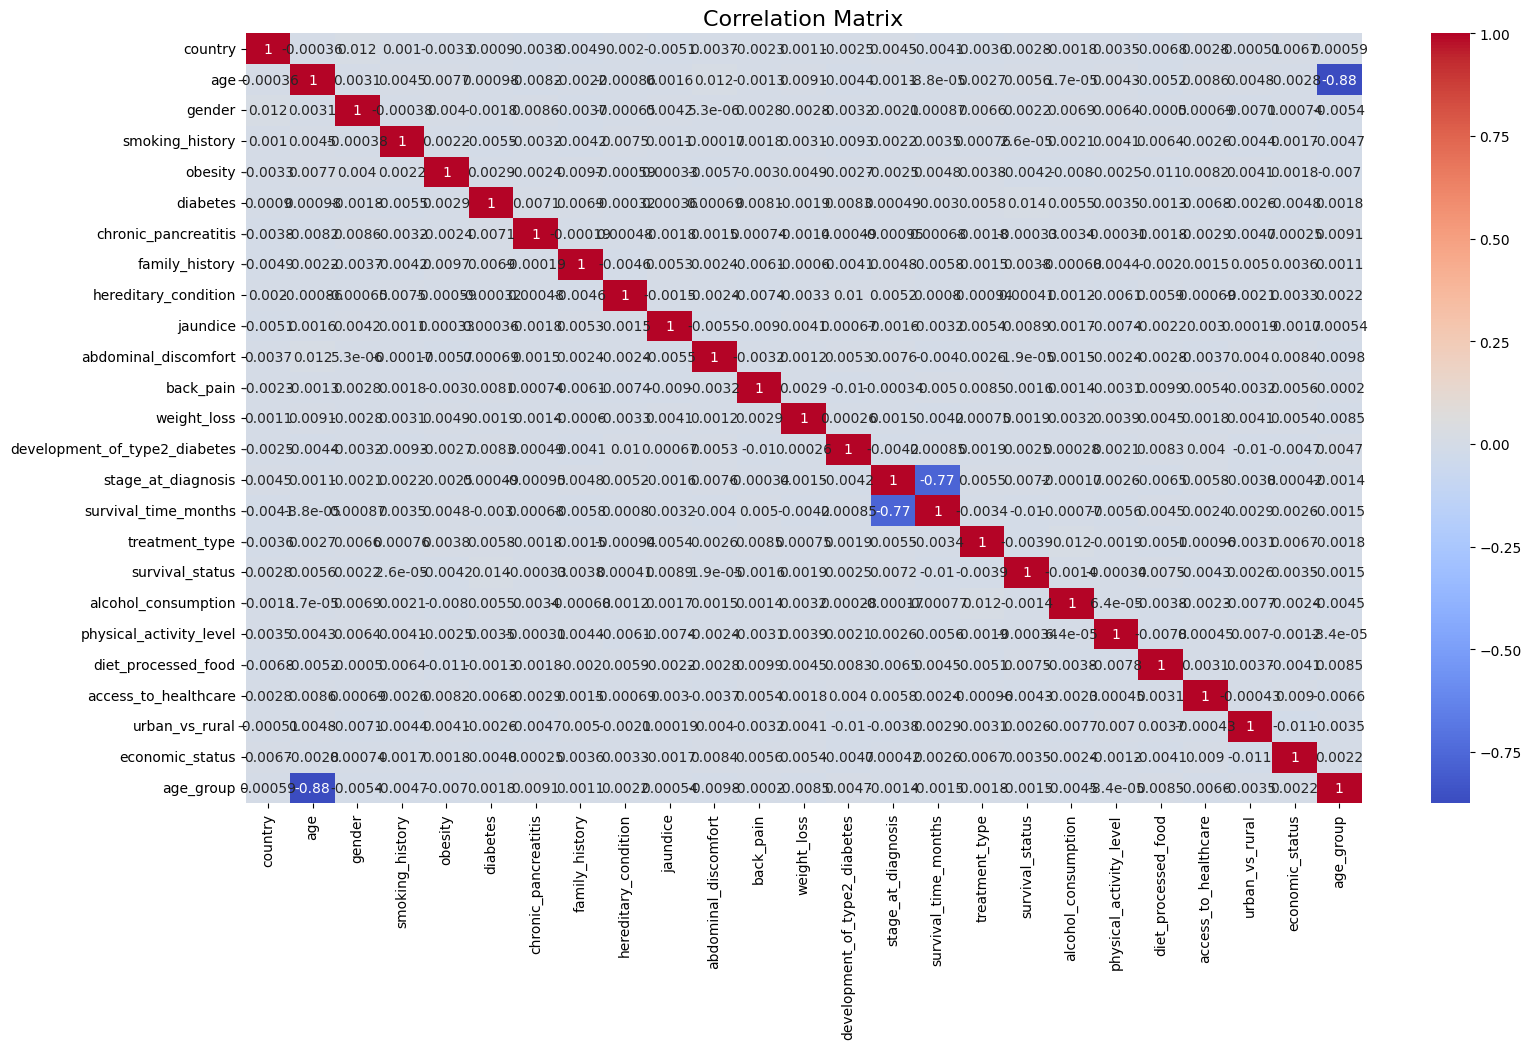

In [16]:
# correlation analysis

label_encoders = {}
for column in df.select_dtypes(include=['object', 'category']).columns:
    label_encoders[column] = LabelEncoder()
    df[column] = label_encoders[column].fit_transform(df[column])

correlation_matrix = df.corr(method='pearson')

plt.figure(figsize=(18, 10))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix", fontsize=16)
plt.show()

---

## Project Progress 4
###  Model Development (Pandas/Keras/TensorFlow/Matplotlib/…)
  - Simple and multiple linear regression
  - Model evaluation using visualization
  - Polynomial regression and pipelines
  - R-squared and MSE for In-Sample Evaluation
  - Prediction and decision making


In [17]:
#  prepare data regression

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

X = df[['age']]   # simple regression
y = df['survival_time_months']

In [18]:
# simple linear regression 

lin_reg = LinearRegression()
lin_reg.fit(X, y)

y_pred = lin_reg.predict(X)

mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)

print("Simple Linear Regression")
print("MSE:", mse)
print("R²:", r2)

Simple Linear Regression
MSE: 0.9999999922847456
R²: 7.715254435325392e-09


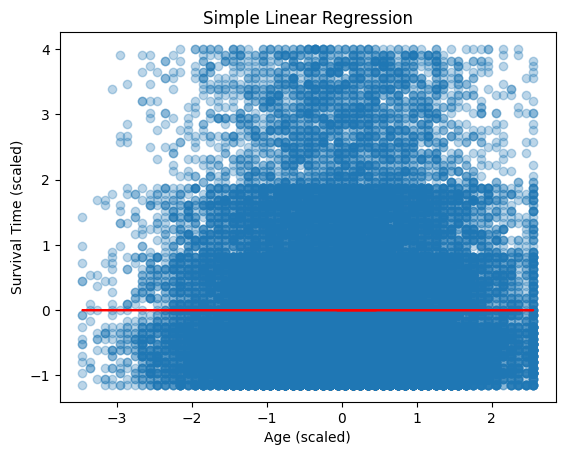

In [19]:
# visualization

plt.scatter(X, y, alpha=0.3)
plt.plot(X, y_pred, color='red')
plt.xlabel("Age (scaled)")
plt.ylabel("Survival Time (scaled)")
plt.title("Simple Linear Regression")
plt.show()

In [20]:
#  multiple linear regression

X_multi = df[['age', 'smoking_history', 'diabetes', 'obesity']]

multi_reg = LinearRegression()
multi_reg.fit(X_multi, y)

y_pred_multi = multi_reg.predict(X_multi)

print("Multiple Linear Regression")
print("MSE:", mean_squared_error(y, y_pred_multi))
print("R²:", r2_score(y, y_pred_multi))

Multiple Linear Regression
MSE: 0.9999559925981186
R²: 4.4007401881374086e-05


In [21]:
# polynomial regression

from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

poly_model = make_pipeline(
    PolynomialFeatures(degree=2),
    LinearRegression()
)

poly_model.fit(X, y)
y_pred_poly = poly_model.predict(X)

print("Polynomial Regression (degree=2)")
print("MSE:", mean_squared_error(y, y_pred_poly))
print("R²:", r2_score(y, y_pred_poly))


Polynomial Regression (degree=2)
MSE: 0.9999951778533491
R²: 4.822146650873549e-06


In [22]:
# prediction and decision making

example_age = pd.DataFrame([[0.5]], columns=['age'])  # above-average age (scaled)
predicted_survival = lin_reg.predict(example_age)

print("Predicted survival time (scaled):", predicted_survival)

Predicted survival time (scaled): [-4.39182603e-05]


---

## Project Progress 5
### Model evaluation (sklearn)
  - Model evaluation
  - Over-fitting, under-fitting, and model selection
  - Ridge regression
  - Grid search
  - Model refinement


In [23]:
# prepare data and train test split

from sklearn.model_selection import train_test_split

X = df_encoded.drop(columns=['survival_status'])
y = df_encoded['survival_status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [24]:
# Check for non-numeric columns in X_train
print("Non-numeric columns in X_train:")
print(X_train.select_dtypes(include=['object', 'category']).columns.tolist())

Non-numeric columns in X_train:
[]


In [26]:
# logistic regression 

import warnings
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

warnings.filterwarnings('ignore')

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

y_train_pred = log_reg.predict(X_train)
y_test_pred = log_reg.predict(X_test)

print("Logistic Regression (Train)")
print(classification_report(y_train, y_train_pred))

print("Logistic Regression (Test)")
print(classification_report(y_test, y_test_pred))

Logistic Regression (Train)
              precision    recall  f1-score   support

           0       0.87      1.00      0.93     34859
           1       0.00      0.00      0.00      5137

    accuracy                           0.87     39996
   macro avg       0.44      0.50      0.47     39996
weighted avg       0.76      0.87      0.81     39996

Logistic Regression (Test)
              precision    recall  f1-score   support

           0       0.87      1.00      0.93      8715
           1       0.00      0.00      0.00      1285

    accuracy                           0.87     10000
   macro avg       0.44      0.50      0.47     10000
weighted avg       0.76      0.87      0.81     10000



In [27]:
# overfitting and underfitting 

from sklearn.metrics import accuracy_score

print("Train accuracy:", accuracy_score(y_train, y_train_pred))
print("Test accuracy :", accuracy_score(y_test, y_test_pred))

Train accuracy: 0.8715621562156216
Test accuracy : 0.8715


In [28]:
# ridge regression

from sklearn.linear_model import RidgeClassifier

ridge = RidgeClassifier(alpha=1.0)
ridge.fit(X_train, y_train)

y_train_pred_ridge = ridge.predict(X_train)
y_test_pred_ridge = ridge.predict(X_test)

print("Ridge Classifier (Train)")
print(classification_report(y_train, y_train_pred_ridge))

print("Ridge Classifier (Test)")
print(classification_report(y_test, y_test_pred_ridge))

Ridge Classifier (Train)
              precision    recall  f1-score   support

           0       0.87      1.00      0.93     34859
           1       0.00      0.00      0.00      5137

    accuracy                           0.87     39996
   macro avg       0.44      0.50      0.47     39996
weighted avg       0.76      0.87      0.81     39996

Ridge Classifier (Test)
              precision    recall  f1-score   support

           0       0.87      1.00      0.93      8715
           1       0.00      0.00      0.00      1285

    accuracy                           0.87     10000
   macro avg       0.44      0.50      0.47     10000
weighted avg       0.76      0.87      0.81     10000



In [31]:
# random forest

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_train_pred_rf = rf.predict(X_train)
y_test_pred_rf = rf.predict(X_test)

print("Random Forest (Train)")
print(classification_report(y_train, y_train_pred_rf))

print("Random Forest (Test)")
print(classification_report(y_test, y_test_pred_rf))

Random Forest (Train)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     34859
           1       1.00      1.00      1.00      5137

    accuracy                           1.00     39996
   macro avg       1.00      1.00      1.00     39996
weighted avg       1.00      1.00      1.00     39996

Random Forest (Test)
              precision    recall  f1-score   support

           0       0.87      1.00      0.93      8715
           1       0.00      0.00      0.00      1285

    accuracy                           0.87     10000
   macro avg       0.44      0.50      0.47     10000
weighted avg       0.76      0.87      0.81     10000



In [29]:
# grid seacrh

from sklearn.model_selection import GridSearchCV

param_grid = {
    'alpha': [0.01, 0.1, 1, 10, 100]
}

grid = GridSearchCV(
    RidgeClassifier(),
    param_grid,
    cv=5,
    scoring='f1'
)

grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best CV score:", grid.best_score_)

Best parameters: {'alpha': 0.01}
Best CV score: 0.0


In [30]:
# model refinement 

best_ridge = grid.best_estimator_

y_test_pred_best = best_ridge.predict(X_test)

print("Tuned Ridge (Test)")
print(classification_report(y_test, y_test_pred_best))


Tuned Ridge (Test)
              precision    recall  f1-score   support

           0       0.87      1.00      0.93      8715
           1       0.00      0.00      0.00      1285

    accuracy                           0.87     10000
   macro avg       0.44      0.50      0.47     10000
weighted avg       0.76      0.87      0.81     10000



In [35]:
# comparison between models

X = df_encoded.drop('survival_status', axis=1)
y = df_encoded['survival_status'] 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    "Logistic Regression": LogisticRegression(max_iter=10000, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=3),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, random_state=42)
}

def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)  
    y_pred = model.predict(X_test)  
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    
    return accuracy, precision, recall, f1

results = []

for name, model in models.items():
    accuracy, precision, recall, f1 = evaluate_model(model, X_train, X_test, y_train, y_test)
    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.8715,0.759512,0.8715,0.811662
1,KNN,0.8358,0.772196,0.8358,0.800238
2,Decision Tree,0.7469,0.773242,0.7469,0.759506
3,Random Forest,0.8715,0.759512,0.8715,0.811662
4,XGBoost,0.8699,0.772312,0.8699,0.811245
